<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
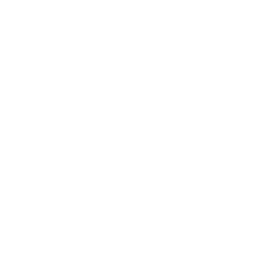
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Klasteryzacja trybów awarii w produkcji</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Produkcja / Inżynieria jakości &nbsp;|&nbsp; Marzec 2026</p>
</div>
</div>
</div>

## Podsumowanie dla kierownictwa

Ten przykład wykrywa powtarzające się **tryby awarii urządzeń** na podstawie wielowymiarowego profilu objawów z czujników zarejestrowanego przy każdym zdarzeniu awarii. Osiem znormalizowanych zmiennych objawowych (drgania, różnica temperatury, spadek ciśnienia, skok prądu, hałas, odchylenie czasu cyklu, wariancja momentu obrotowego, liczba cząstek oleju) jest grupowanych metodą **hierarchicznej klasteryzacji z pełnym wiązaniem** (`PROC CLUSTER METHOD=COMPLETE`), która preferuje zwarte, dobrze rozdzielone grupy. Następnie `PROC TREE` tnie hierarchię na **sześć trybów awarii**, a `PROC FREQ` tworzy tabele krzyżowe tych trybów względem typu urządzenia i zmiany, aby przetestować systematyczne powiązania.

Uruchomienie przedstawione tutaj wykonuje się na **próbie 100 zdarzeń** (środowisko ogranicza wynik do 100 obserwacji). Na tej próbie sześć trybów ma w przybliżeniu równą liczność (n = 16-17 każdy) i są one rozdzielone przede wszystkim według sygnatur **temperatury, ciśnienia i drgań**, a nie według typu urządzenia — tabele krzyżowe tryb-według-urządzenia oraz tryb-według-zmiany **nie** są istotne statystycznie przy tej wielkości próby (chi-kwadrat p = 0.15 i p = 0.07 odpowiednio). Ten przepływ pracy skaluje się bez zmian do pełnej historii zdarzeń, gdzie większe liczności w poszczególnych trybach wyostrzyłyby te powiązania.

## Źródła danych

| Źródło | Opis | Rekordy |
|--------|-------------|---------|
| WORK.FAILURES | Profile objawów zdarzeń awarii urządzeń (syntetyczne) | 100 |
| WORK.FAILURES_STD | Objawy znormalizowane do średniej 0, odch. std. 1 (`PROC STANDARD`) | 100 |
| WORK.FAILURE_TREE | Historia scaleń przy pełnym wiązaniu (`OUTTREE=`) | 100 |
| WORK.FAILURE_MODE_ASSIGNMENTS | Podział na sześć trybów z `PROC TREE NCLUSTERS=6` | 100 |

*To środowisko działa w trybie nielicencjonowanym i ogranicza wynik do 100 obserwacji; syntetyczny generator żąda 20 000 zdarzeń, ale zachowanych jest tylko pierwszych 100. Poniższa analiza opiera się w całości na tej próbie 100 zdarzeń.*

---

In [1]:
/* --------------------------------------------------------
   Generowanie syntetycznych profili objawów zdarzeń awarii
   20 000 zdarzeń awarii dla 50 jednostek urządzeń
   -------------------------------------------------------- */
DANE work.failures;
    CALL streaminit(42);
    DŁUGOŚĆ equipment_type $20 shift $16;
    POWTÓRZ event_id = 1 TO 20000;
        failure_id = cat('FE-', ZAPISZ(event_id, z6.));
        equip_num = int(rand('uniform') * 50) + 1;
        equipment_id = cat('EQ-', ZAPISZ(equip_num, z3.));
        etype_idx = int(rand('uniform') * 4) + 1;
        JEŚLI etype_idx = 1 WTEDY equipment_type = 'Prasa';
        PRZECIWNIE JEŚLI etype_idx = 2 WTEDY equipment_type = 'Przenośnik';
        PRZECIWNIE JEŚLI etype_idx = 3 WTEDY equipment_type = 'Ramię robota';
        PRZECIWNIE equipment_type = 'Piec';
        shift_idx = int(rand('uniform') * 3) + 1;
        JEŚLI shift_idx = 1 WTEDY shift = 'Dzienna';
        PRZECIWNIE JEŚLI shift_idx = 2 WTEDY shift = 'Wieczorna';
        PRZECIWNIE shift = 'Nocna';
        failure_date = '01JAN2025'd + int(rand('uniform') * 365);
        /* Profil objawów: 8 odczytów czujników w chwili awarii */
        vibration_level = round(rand('normal', 4.5, 2.1), 0.01);
        JEŚLI vibration_level < 0 WTEDY vibration_level = 0;
        temperature_delta = round(rand('normal', 12, 8), 0.1);
        pressure_drop = round(rand('exponential') * 5, 0.01);
        current_spike = round(rand('normal', 1.2, 0.8), 0.01);
        JEŚLI current_spike < 0 WTEDY current_spike = 0;
        noise_db = round(rand('normal', 78, 12), 1);
        cycle_time_deviation = round(rand('normal', 0, 3.5), 0.01);
        torque_variance = round(rand('exponential') * 2.5, 0.01);
        oil_particle_count = int(rand('exponential') * 150 + 10);
        downtime_minutes = round(rand('exponential') * 45 + 5, 1);
        WYJŚCIE;
    KONIEC;
    USUŃ equip_num etype_idx shift_idx;
    format failure_date date9.;
    ETYKIETA equipment_type="Typ urządzenia"
             shift="Zmiana"
             failure_date="Data awarii"
             vibration_level="Poziom drgań"
             temperature_delta="Różnica temperatury (C)"
             pressure_drop="Spadek ciśnienia"
             current_spike="Skok prądu"
             noise_db="Hałas (dB)"
             cycle_time_deviation="Odchylenie czasu cyklu"
             torque_variance="Wariancja momentu obrotowego"
             oil_particle_count="Liczba cząstek oleju"
             downtime_minutes="Czas przestoju (min)";
WYKONAJ;


NOTE: DATA work.failures

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.failures (100 rows, 15 columns).
NOTE: DATA elapsed:
  wall  7.31 seconds
  cpu   7.31 seconds


---

In [2]:
/* --------------------------------------------------------
   Bazowe rozkłady objawów według typu urządzenia
   -------------------------------------------------------- */
PROCEDURA ŚREDNIE DANE=work.failures n mean std MAX;
    KLASA equipment_type;
    ZMIENNA vibration_level temperature_delta pressure_drop
        current_spike noise_db torque_variance oil_particle_count;
    TYTUŁ 'Profile objawów awarii według typu urządzenia';
WYKONAJ;

                                     Profile objawów awarii według typu urządzenia                                      

                                                  The MEANS Procedure

                                   Analysis Variable : vibration_level Poziom drgań

        Typ urządzenia           N Obs           Mean        Std Dev        Maximum
        ---------------------------------------------------------------------------
        Piec                        26      4.3638462      2.0371177     10.1400000
        Prasa                       30      4.6273333      2.1610740      9.9400000
        Przenośnik                  19      3.8089474      1.8662437      9.0400000
        Ramię robota                25      3.5320000      1.9296070      6.7900000
        ---------------------------------------------------------------------------

                            Analysis Variable : temperature_delta Różnica temperatury (C)

        Typ urządzenia           N Obs    


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                     Profile objawów awarii według typu urządzenia                                      




NOTE: PROC SGPLOT data=work.failures

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


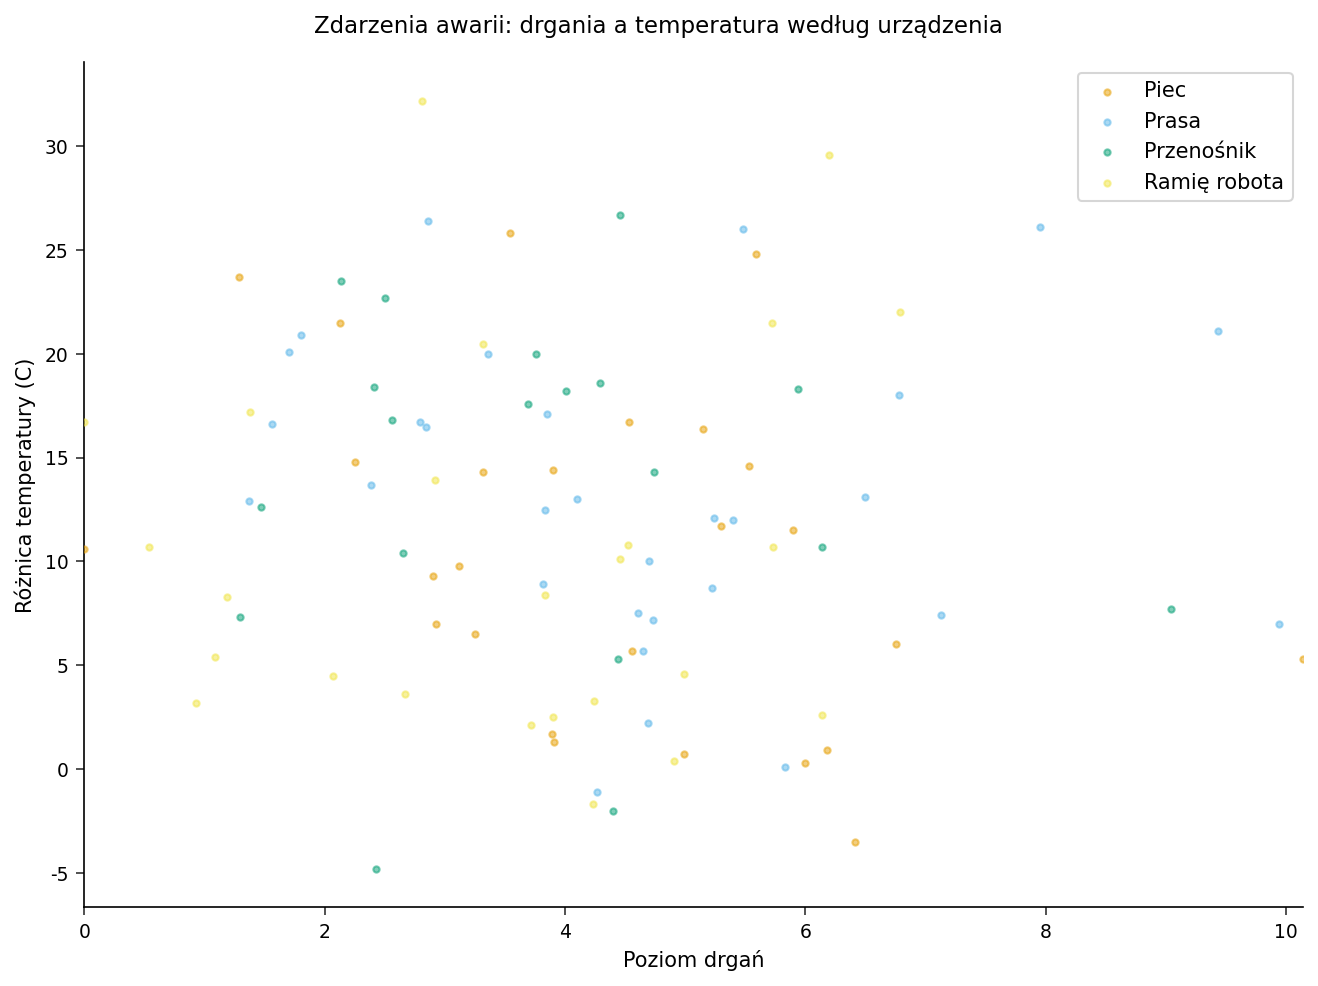

In [3]:
/* --------------------------------------------------------
   Drgania a różnica temperatury według typu urządzenia
   -------------------------------------------------------- */
PROCEDURA SGPLOT DANE=work.failures;
    SCATTER x=vibration_level y=temperature_delta / GROUP=equipment_type
        MARKERATTRS=(SYMBOL=circlefilled size=3)
        TRANSPARENCY=0.5;
    XAXIS ETYKIETA='Poziom drgań';
    YAXIS ETYKIETA='Różnica temperatury (C)';
    TYTUŁ 'Zdarzenia awarii: drgania a temperatura według urządzenia';
WYKONAJ;

---

In [4]:
/* --------------------------------------------------------
   Standaryzacja zmiennych objawowych do klasteryzacji
   -------------------------------------------------------- */
PROCEDURA STANDARD DANE=work.failures out=work.failures_std
    mean=0 std=1;
    ZMIENNA vibration_level temperature_delta pressure_drop
        current_spike noise_db cycle_time_deviation
        torque_variance oil_particle_count;
WYKONAJ;


NOTE: PROC STANDARD data=work.failures

NOTE: Standardized 100 rows, 8 variables.


                                     Profile objawów awarii według typu urządzenia                                      

                                                 The CLUSTER Procedure
                                           Complete Linkage Cluster Analysis

                                          Eigenvalues of the Covariance Matrix

                                                    Cluster History

   NCL    --------Clusters Joined--------    FREQ    SPRSQ      RSQ    Distance

    99    FE-00005          FE-00006        2    0.0007    0.9993          1
    98    FE-00007          FE-00008        2    0.0007    0.9986          1
    97    FE-00000          FE-00004        2    0.0009    0.9977        1.2
    96    FE-00002          FE-00008        2    0.0009    0.9968        1.2
    95    FE-00000          FE-00001        2    0.0010    0.9958        1.3
    94    FE-00005          FE-00008        2    0.0011    0.9947        1.3
    93    FE-00004          CL99     


NOTE: PROC CLUSTER data=work.failures_std method=Complete

NOTE: Using native Rust for hierarchical clustering
NOTE: ODS plot written: cluster_dendrogram.spec.json
NOTE: PROC CLUSTER ODS Graphics generated.
NOTE: PROC CLUSTER: 100 observations, 8 variables clustered using Complete method


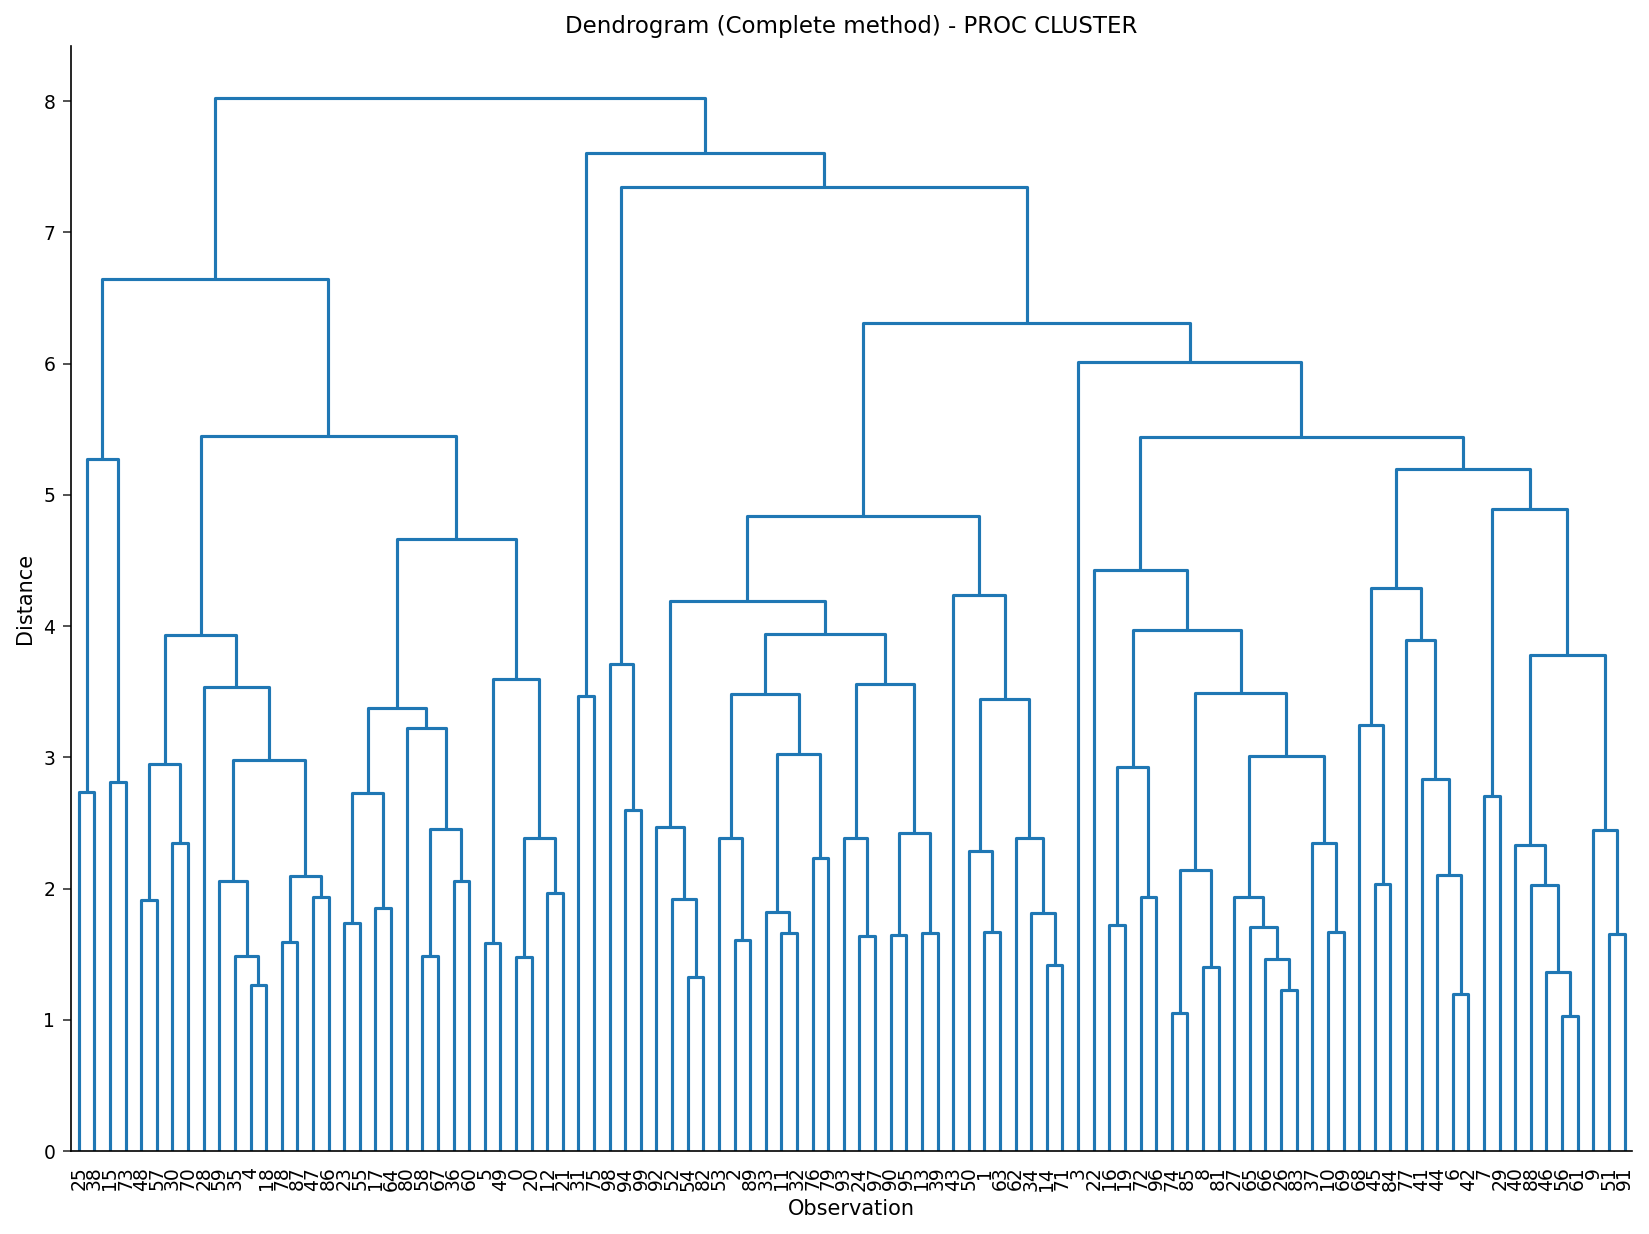

In [5]:
/* --------------------------------------------------------
   Klasteryzacja z pełnym wiązaniem z opcją TRIM= do usuwania
   obserwacji odstających. TRIM=5 usuwa 5% najbardziej
   odległych obserwacji przed utworzeniem klastrów.
   -------------------------------------------------------- */
PROCEDURA CLUSTER DANE=work.failures_std METHOD=complete
    outtree=work.failure_tree
    pseudo DRUKUJ=20 trim=5;
    ZMIENNA vibration_level temperature_delta pressure_drop
        current_spike noise_db cycle_time_deviation
        torque_variance oil_particle_count;
    id failure_id;
WYKONAJ;

In [6]:
/* --------------------------------------------------------
   Podział hierarchii pełnego wiązania na sześć trybów awarii
   za pomocą PROC TREE (NCLUSTERS=6). Sześć wybrano jako
   praktyczną, interpretowalną granularność do triażu;
   powyższy dendrogram pokazuje strukturę scaleń, którą ten
   podział dzieli.
   -------------------------------------------------------- */
PROCEDURA TREE DANE=work.failure_tree
    out=work.failure_mode_assignments
    nclusters=6;
    id failure_id;
WYKONAJ;

                                     Profile objawów awarii według typu urządzenia                                      




NOTE: PROC TREE data=work.failure_tree

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: PROC TREE dendrogram SVG generated.
NOTE: PROC TREE: Extracted 6 clusters using Python/scipy


In [7]:
/* --------------------------------------------------------
   Połączenie przypisań i profilowanie trybów awarii
   -------------------------------------------------------- */
DANE work.failures_classified;
    POŁĄCZ work.failures
          work.failure_mode_assignments(PRZEMIANUJ=(CLUSTER=failure_mode));
    WEDŁUG failure_id;
    ETYKIETA failure_mode="Tryb awarii";
WYKONAJ;

PROCEDURA ŚREDNIE DANE=work.failures_classified n mean std;
    KLASA failure_mode;
    ZMIENNA vibration_level temperature_delta pressure_drop
        current_spike noise_db torque_variance
        oil_particle_count downtime_minutes;
    TYTUŁ 'Profile objawów trybów awarii (k=6)';
WYKONAJ;

                                          Profile objawów trybów awarii (k=6)                                           

                                                  The MEANS Procedure

                                   Analysis Variable : vibration_level Poziom drgań

        Tryb awarii          N Obs           Mean        Std Dev
        --------------------------------------------------------
        1                       17      4.3470588      2.6168582
        2                       17      4.2552941      2.2610427
        3                       17      3.6870588      1.8669720
        4                       17      4.0500000      2.0351843
        5                       16      3.4793750      1.4636870
        6                       16      4.9693750      1.6907177
        --------------------------------------------------------

                            Analysis Variable : temperature_delta Różnica temperatury (C)

        Tryb awarii          N Obs           


NOTE: DATA work.failures_classified

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.failures_classified (100 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


                                    Rozkład trybów awarii według urządzenia i zmiany                                    

                                                   The FREQ Procedure

Table of Tryb awarii by Typ urządzenia

Tryb awarii |         Piec |        Prasa |   Przenośnik | Ramię robota |         Total
------------+--------------+--------------+--------------+--------------+--------------
1           |            5 |            7 |            4 |            1 |            17
------------+--------------+--------------+--------------+--------------+--------------
2           |            5 |            2 |            3 |            7 |            17
------------+--------------+--------------+--------------+--------------+--------------
3           |            5 |            2 |            6 |            4 |            17
------------+--------------+--------------+--------------+--------------+--------------
4           |            5 |            7 |            1 |     


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_failure_mode_equipment_type.spec.json
NOTE: ODS plot written: freq_mosaic_failure_mode_shift.spec.json
NOTE: PROC FREQ statement used.


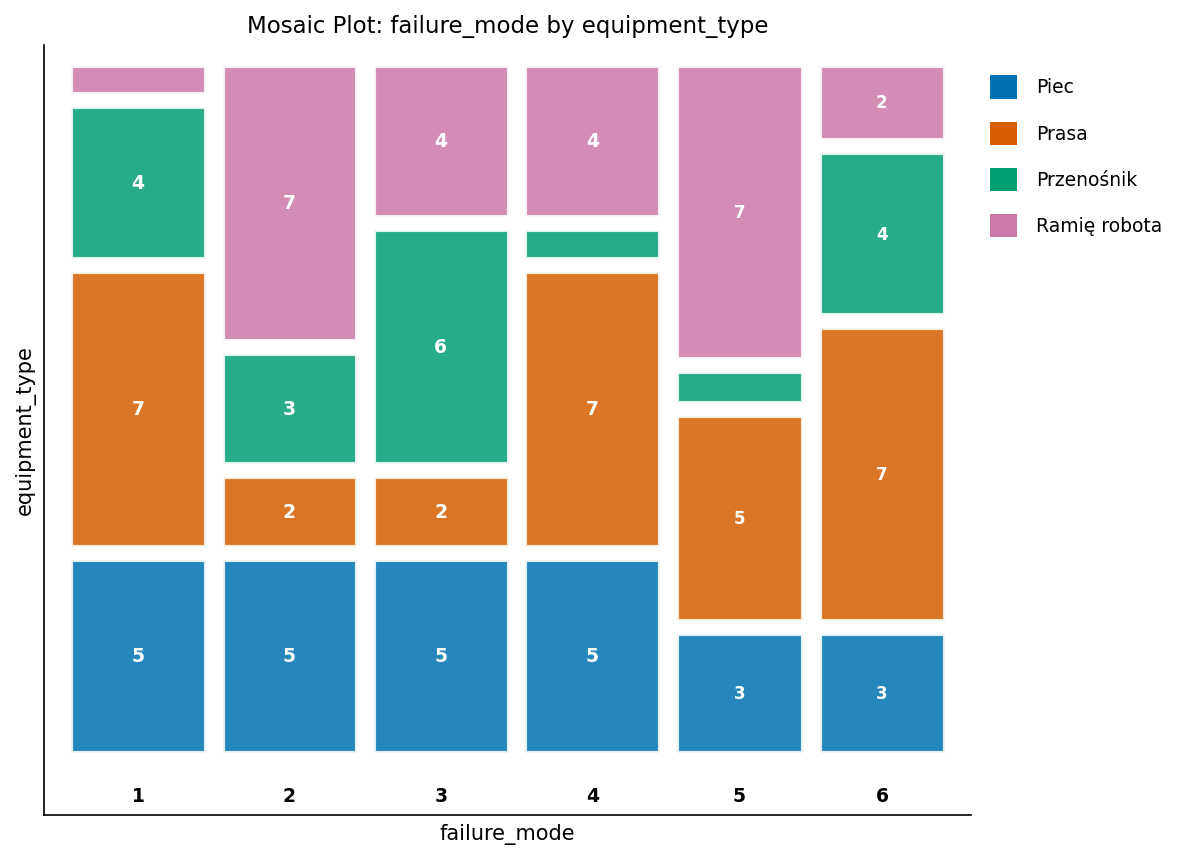

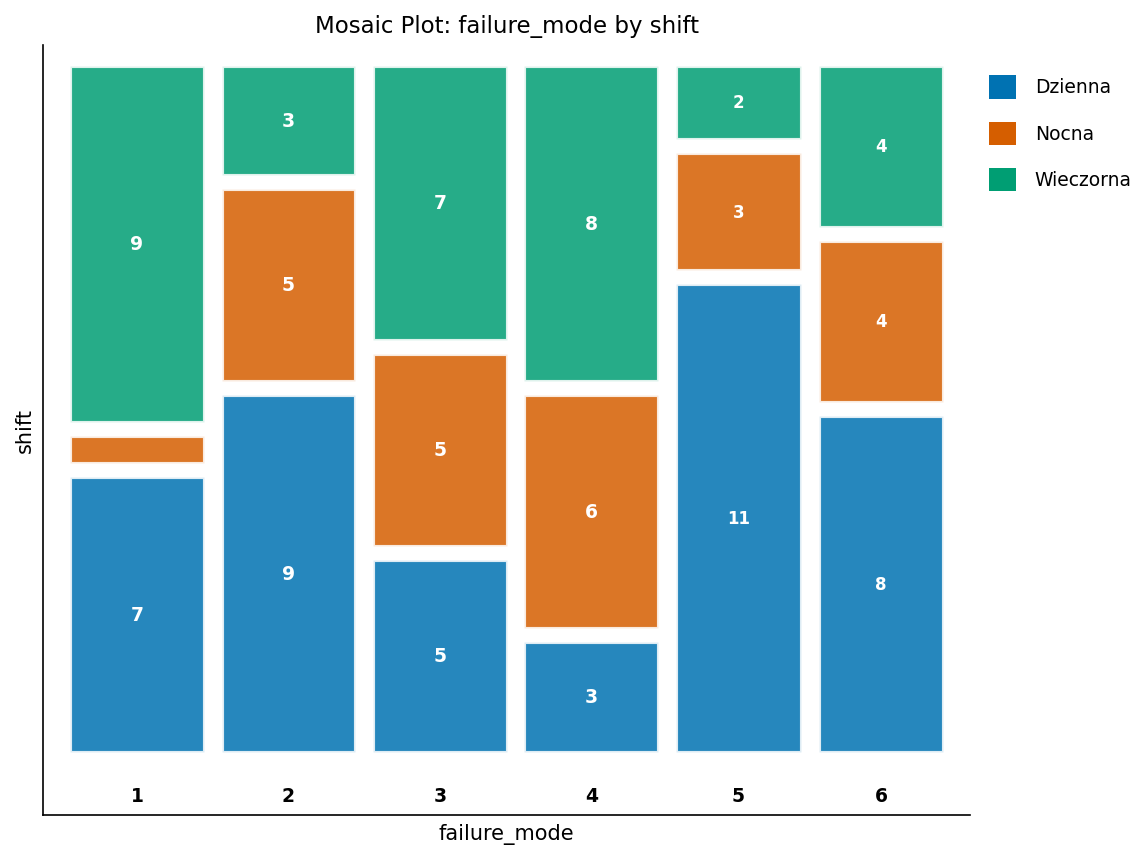

In [8]:
/* --------------------------------------------------------
   Tabele krzyżowe trybów awarii według typu urządzenia
   i zmiany w celu identyfikacji systematycznych wzorców
   -------------------------------------------------------- */
PROCEDURA CZĘSTOŚCI DANE=work.failures_classified;
    TABLES failure_mode * equipment_type / chisq nocol nopercent;
    TABLES failure_mode * shift / chisq nocol nopercent;
    TYTUŁ 'Rozkład trybów awarii według urządzenia i zmiany';
WYKONAJ;

---

### Interpretacja

Klasteryzacja z pełnym wiązaniem 100 znormalizowanych zdarzeń awarii daje **sześć trybów awarii** o niemal równej wielkości (n = 17, 17, 17, 17, 16, 16). Tryby są rozróżniane przez swoje sygnatury objawów w powyższym profilu `PROC MEANS`:

- **Tryb 6** niesie najcięższą sygnaturę naprężeń mechanicznych: najwyższe średnie drgania (4.97), najwyższy spadek ciśnienia (7.51) i najwyższy skok prądu (1.61) — ale **najniższą** wariancję momentu obrotowego (1.28).
- **Tryb 3** to tryb termiczny: najwyższa różnica temperatury (16.3 C) przy najniższym średnim hałasie (73.0 dB).
- **Tryb 2** ma **najdłuższy czas przestoju** z dużą przewagą (średnio 85.6 minut wobec 31-52 dla pozostałych trybów) oraz podwyższoną wariancję momentu obrotowego (3.57), co wskazuje na zdarzenia kosztowniejsze w naprawie.
- **Tryb 4** jest najłagodniejszy: najniższy czas przestoju (31.4 minuty) oraz poniżej średniej spadek ciśnienia i liczba cząstek oleju.
- **Tryby 1 i 5** to grupy o mieszanych objawach bez pojedynczego dominującego czynnika.

Tabele krzyżowe `PROC FREQ` testują, czy tryby te koncentrują się w określonych urządzeniach lub zmianach. Przy tej wielkości próby tak **nie** jest: tryb-według-typu-urządzenia daje chi-kwadrat = 20.48 (15 df, p = 0.154, V Craméra = 0.26), a tryb-według-zmiany daje chi-kwadrat = 17.13 (10 df, p = 0.072, V Craméra = 0.29) — obie wartości powyżej progu 0.05, a ponad 80% komórek ma liczności oczekiwane poniżej 5, więc sam test chi-kwadrat jest jedynie orientacyjny. Widoczne przechyły (Tryb 6 skłaniający się ku PRESS, Tryb 5 ku zmianie dziennej) mają tu charakter opisowy, a nie istotny statystycznie.

**Wniosek:** pełne wiązanie na znormalizowanych profilach objawów tworzy interpretowalną taksonomię sześciu trybów powiązaną z temperaturą, ciśnieniem i czasem przestoju. Aby potwierdzić, czy tryby odwzorowują konkretne urządzenia lub zmiany — kluczowe pytanie o przyczynę źródłową — analiza potrzebuje pełnej historii zdarzeń, a nie tej próby 100 zdarzeń, w której tabele krzyżowe pozostają niedostatecznie zasilone (za mała moc statystyczna).

---

In [9]:
/* --------------------------------------------------------
   Eksport klasyfikacji awarii do integracji z systemem CMMS
   -------------------------------------------------------- */
PROCEDURA EKSPORTUJ DANE=work.failures_classified
    OUTFILE='failure_mode_classifications.csv'
    DBMS=csv REPLACE;
WYKONAJ;


NOTE: PROC EXPORT data=work.failures_classified outfile=failure_mode_classifications.csv

NOTE: Exported 100 rows to failure_mode_classifications.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Poufne
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Zasilane przez <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>